# <center> <img src="figs/LogoUFSCar.jpg" alt="Logo UFSCar" width="110" align="left"/>  <br/> <center>Universidade Federal de São Carlos (UFSCar)<br/><font size="4"> Departamento de Computação, campus Sorocaba</center></font>
</p>

<font size="4"><center><b>Disciplina: Processamento de Linguagem Natural</b></center></font>

<font size="3"><center>Prof. Dr. Tiago A. Almeida</center></font>

## <center>Projeto Final — Classificação Automática de Documentos Jurídicos</center>

**Nome**: Anderson Cristiano Sassaki Gonçalves

**RA**: 821675

**Nome**: Lorenzo Grippo Chiachio

**RA**: 823917

---

### Contexto do problema

O Supremo Tribunal Federal (STF) recebe diariamente um volume enorme de peças processuais digitalizadas. Saber automaticamente o tipo do documento é o primeiro passo de qualquer automação de triagem jurídica. Este projeto usa uma partição da base **VICTOR**, contendo o texto bruto de páginas de processos do STF, rotuladas em cinco categorias:

| Código | Categoria |
|---|---|
| 0 | Acórdão |
| 1 | Agravo de Recurso Extraordinário (ARE) |
| 2 | Despacho |
| 3 | Recurso Extraordinário (RE) |
| 4 | Sentença |

O desafio combina três dificuldades típicas de PLN jurídico em português: **ruído de extração/OCR** , **vocabulário técnico-formulaico** e **forte desbalanceamento de classes**.

### Como o notebook está organizado

Este notebook implementa um pipeline completo de classificação de texto: exploração dos dados → limpeza → baselines clássicos → embeddings densos → modelo de linguagem ajustado (Legal-BERTimbau Large). O arquivo oficial submetido na competição é `submission_bert_large_final.csv`. A variante `submission_bert_large_final-cheating.csv` que aparece na Seção 7/8 é **apenas uma análise de um exploit estrutural por `Id`/Viterbi**, documentada por transparência metodológica, e **nunca deve ser tratada como nossa submissão válida**.

O desenvolvimento está organizado nas oito etapas obrigatórias do projeto:

1. **Análise de dados:** entendimento do volume, balanceamento e características textuais do corpus;
2. **Pré-processamento e limpeza:** normalização do texto ruidoso de OCR e tratamento de rótulos ausentes;
3. **Representação computacional:** comparação entre representações esparsas (TF-IDF) e densas (embeddings);
4. **Tarefas básicas de PLN:** extração de sinais jurídicos e features linguísticas/PoS/NER;
5. **Modelos de classificação clássicos:** baselines com Naïve Bayes, Regressão Logística, SVM e SGD;
6. **Modelos profundos de categorização:** classificadores sobre embeddings densos contextualizados;
7. **Adaptação de modelos de linguagem:** fine-tuning de um BERTimbau jurídico (Legal-BERTimbau Large);
8. **Análise de resultados:** comparação de todas as submissões geradas.


---
## Preparação do ambiente

As células seguintes verificam as dependências, definem os diretórios do projeto, importam as funções implementadas em `scripts/` (organizadas por etapa: `analise_exploratoria.py`, `preprocessamento.py`, `experimentos.py` e `analise_resultados.py`) e selecionam automaticamente o melhor dispositivo disponível (`cuda`, `mps` ou `cpu`). Essa preparação é comum a todas as etapas do pipeline e, por isso, **não faz parte da numeração das oito seções** pedidas no enunciado.

Para manter a reprodutibilidade do resultado final sem tornar o notebook excessivamente longo (e mais difícil de revisar), o treinamento completo do Legal-BERTimbau Large fica encapsulado no script `train_bert_large_final.py`. O notebook mostra exatamente como esse script é chamado, quais artefatos ele gera e como interpretar as submissões produzidas, mas a execução pesada (que demanda GPU e leva horas) permanece opcional e desligada por padrão.


In [1]:
import importlib.util
import subprocess
import sys

BASE_MODULES = ["pandas", "numpy", "sklearn", "matplotlib", "seaborn", "joblib"]
ADVANCED_MODULES = ["torch", "transformers", "datasets", "sentence_transformers", "accelerate"]

missing_base = [pkg for pkg in BASE_MODULES if importlib.util.find_spec(pkg) is None]
if missing_base:
    print("Instalando dependências base ausentes:", missing_base)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"])
else:
    print("Dependências base já disponíveis.")

missing_advanced = [pkg for pkg in ADVANCED_MODULES if importlib.util.find_spec(pkg) is None]
if missing_advanced:
    print("Instalando dependências avançadas ausentes:", missing_advanced)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-advanced.txt"])
else:
    print("Dependências avançadas já disponíveis.")

importlib.invalidate_caches()
print("Ambiente pronto para executar o pipeline completo.")


Dependências base já disponíveis.
Dependências avançadas já disponíveis.
Ambiente pronto para executar o pipeline completo.


Dependências resolvidas, o ambiente está pronto. A célula a seguir resolve os caminhos do projeto (`data/`, `outputs/`, `models/`), garante que as pastas de saída existam, adiciona `scripts/` ao `sys.path` para permitir os imports dos módulos do projeto, e importa todas as funções que serão usadas ao longo do notebook — uma por seção. Por fim, `auto_runtime_profile` inspeciona o hardware disponível (CPU/CUDA/MPS) e devolve um perfil de execução: ele decide automaticamente o tamanho de batch e a precisão numérica recomendados para o Transformer, sem exigir que configuremos manualmente flags diferentes em cada máquina.

In [2]:
from pathlib import Path
import json
import os
import platform
import subprocess
import sys

import numpy as np
import pandas as pd

PROJECT_DIR = Path.cwd()
if (PROJECT_DIR / "template-implementacao" / "scripts").exists():
    PROJECT_DIR = PROJECT_DIR / "template-implementacao"
PROJECT_DIR = PROJECT_DIR.resolve()
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
MODEL_DIR = PROJECT_DIR / "models"
CACHE_DIR = OUTPUT_DIR / "cache"
REPORT_DIR = OUTPUT_DIR / "reports"

for directory in [OUTPUT_DIR, MODEL_DIR, CACHE_DIR, REPORT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

sys.path.append(str((PROJECT_DIR / "scripts").resolve()))

from analise_exploratoria import (
    add_text_statistics,
    get_top_terms,
    load_competition_data,
    plot_class_distribution,
    plot_text_length_distribution,
    plot_top_terms,
    summarize_dataset,
    validate_schema,
    split_labeled_unlabeled,
)
from preprocessamento import (
    CLASS_NAMES,
    TextPreprocessConfig,
    add_clean_text_column,
    extract_basic_nlp_features,
    extract_legal_signal_features,
)
from experimentos import (
    ExperimentConfig,
    auto_runtime_profile,
    build_embedding_classifier_zoo,
    build_sentence_embedding_matrix,
    build_chunked_sentence_embedding_matrix,
    build_sparse_model_zoo,

    build_training_set_with_pseudo_labels,
    cross_validate_best_models,

    detect_label_issues_with_cv,
    evaluate_embedding_classifier,
    evaluate_model_zoo,
    fine_tune_transformer_classifier,
    fit_embedding_classifier_on_full_train,
    fit_model_on_full_train,
    generate_embedding_submission,
    generate_submission,
    generate_transformer_submission,

    pseudo_label_unlabeled_samples,
    save_model,
    select_best_model,
    transformer_candidate_models,
)
from analise_resultados import (
    classification_report_frame,
    plot_confusion_matrix,
    plot_metric_comparison,
    rank_results,
    save_results_table,
)

pd.set_option("display.max_colwidth", 160)

runtime_profile = auto_runtime_profile(prefer_transformer=True)
print("Diretório do projeto:", PROJECT_DIR)
print("Perfil automático:", runtime_profile["notes"])
display(pd.DataFrame([
    {
        "device": runtime_profile["device"],
        "advanced_available": runtime_profile["advanced_available"],
        "classical_model_zoo": runtime_profile["classical_model_zoo"],
        "run_classical_baselines": runtime_profile["run_classical_baselines"],
        "run_embeddings": runtime_profile["run_embeddings"],
        "run_transformer": runtime_profile["run_transformer"],
        "batch_transformer": runtime_profile["transformer_batch_size"],
        "max_length_transformer": runtime_profile["transformer_max_length"],
    }
]))


Diretório do projeto: /Users/andersongoncalves/Documents/PLN-Final/template-implementacao
Perfil automático: Complete pipeline enabled automatically on mps.


,device,advanced_available,classical_model_zoo,run_classical_baselines,run_embeddings,run_transformer,batch_transformer,max_length_transformer
0,mps,True,full,True,True,True,2,512


## 1. Análise de dados

Nesta seção, os arquivos `train.csv`, `test.csv` e `sample_submission.csv` são carregados e validados quanto ao schema esperado (colunas presentes, tipos e valores nulos). Amostras com rótulos fora do intervalo `0`–`4` (ou seja, `Category = -1`) são separadas do conjunto rotulado, elas não serão usadas para treino supervisionado, mas são preservadas para uma possível pseudo-rotulagem mais adiante, na Seção 5.

A análise exploratória a seguir examina:

- a distribuição das classes (e o quão desbalanceado é o problema);
- a presença de dados ausentes ou inconsistentes;
- o comprimento dos documentos (em caracteres e palavras) por categoria;
- os termos mais frequentes/discriminativos por categoria, via TF-IDF.

Esses resultados orientam diretamente decisões técnicas tomadas mais adiante: o uso de `f1_macro` como métrica principal, o balanceamento de classes nos modelos, a escolha de n-gramas robustos a ruído de OCR e as estratégias adotadas para lidar com documentos muito longos.

Começamos carregando os três arquivos da competição e validando o schema. `split_labeled_unlabeled` separa as linhas com `Category` válida (usadas como treino supervisionado) das linhas com `Category = -1` (sem rótulo confiável).

In [3]:
train_df, test_df, sample_df = load_competition_data(DATA_DIR)
schema_report = validate_schema(train_df, test_df, sample_df)
train_labeled, train_unlabeled = split_labeled_unlabeled(train_df)

print(f"Total no train.csv: {len(train_df)}")
print(f"Amostras rotuladas válidas: {len(train_labeled)}")
print(f"Amostras sem rótulo válido (Category=-1 ou fora de 0..4): {len(train_unlabeled)}")
print(f"Amostras de teste: {len(test_df)}")

print("Classes usadas no treinamento:")
for label, name in CLASS_NAMES.items():
    print(f"{label}: {name}")

schema_report


Total no train.csv: 22680
Amostras rotuladas válidas: 20412
Amostras sem rótulo válido (Category=-1 ou fora de 0..4): 2268
Amostras de teste: 2521
Classes usadas no treinamento:
0: Acordao
1: Agravo de Recurso Extraordinario (ARE)
2: Despacho
3: Recurso Extraordinario (RE)
4: Sentenca


{'train_shape': (22680, 3),
 'test_shape': (2521, 2),
 'sample_shape': (15, 2),
 'train_missing_columns': [],
 'test_missing_columns': [],
 'sample_missing_columns': [],
 'train_nulls': {'Id': 0, 'Body': 0, 'Category': 0},
 'test_nulls': {'Id': 0, 'Body': 0},
 'duplicated_train_ids': 0,
 'duplicated_test_ids': 0,
 'invalid_category_count': 2268,
 'invalid_category_examples': [{'Id': 9716, 'Category': -1},
  {'Id': 25112, 'Category': -1},
  {'Id': 11274, 'Category': -1},
  {'Id': 20985, 'Category': -1},
  {'Id': 23109, 'Category': -1},
  {'Id': 21386, 'Category': -1},
  {'Id': 21334, 'Category': -1},
  {'Id': 20980, 'Category': -1},
  {'Id': 18398, 'Category': -1},
  {'Id': 7787, 'Category': -1}]}

O `train.csv` tem **22.680 linhas**, das quais **20.412 (≈90%)** possuem rótulo válido e **2.268 (exatamente 10%)** vêm marcadas com `Category = -1`, um padrão de ausência de rótulo bastante regular. O `test.csv` tem **2.521 amostras** a serem classificadas. O relatório de integridade confirma que não há colunas ausentes, não há valores nulos em `Id`/`Body`/`Category`, e não há IDs duplicados em nenhum dos dois arquivos, ou seja, o ruído deste dataset está concentrado no *conteúdo* do texto.

Antes de qualquer estatística, é sempre bom olhar literalmente para os dados, ver como o texto bruto se parece, quais colunas o `test.csv` realmente expõe e o formato de `sample_submission.csv`.

In [4]:
display(train_labeled.head())
display(test_df.head())
if sample_df is not None:
    display(sample_df.head())

,Id,Body,Category
0,12980,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido co...",3
1,9775,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem ativi...",3
2,16061,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedi...",1
3,22984,"{""advocacia geral uniÃ£o procuradoria uniÃ£o paraÃ­ba geral isonomia contido ARTIGO_5Âº caput cf e preceito que garante isonomia entre servidores ativos ina...",3
4,5716,"{""ministÃ©rio fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional campina grande paga pelo inss modo garantir empregado manu...",3


,Id,Body
0,9213,"{""um regime democrática direito qual seja da separação dos poderes recurso inominado parte autora improvido sem condenação ônus sucumbenciais por força conc..."
1,17427,"{""controvérsia fato que requerente participante rpps junto prefeitura municipal roca sales desde que valores atinentes aposentadorias rurais não são essenci..."
2,4753,"{""advocacia geral união procuradoria união paraíba excelentíssimo senhor juiz federal presidente turma recursal dos juizados especiais paraíba união por sua..."
3,4640,"{""advocacia geral união procuradoria união estado paraíba divisão atuação nos juizados especiais federais ARTIGO_169 despesa com pessoal ativo inativo união..."
4,20412,"{""ministério fazenda procuradoria geral fazenda nacional procuradoria seccional fazenda nacional campina grande pede deferimento campina grande de dezembro ..."


,Id,Category
0,7271,3
1,861,4
2,5391,0
3,5192,3
4,5735,1


A visualização confirma a estrutura dos arquivos usados no experimento. O conjunto de treino rotulado contém as colunas `Id`, `Body` e `Category`, em que cada texto jurídico já aparece associado à sua classe. Nas primeiras amostras já é possível observar a predominância da classe `3`, um indício do desbalanceamento que será analisado nas próximas etapas. O conjunto de teste mantém a mesma estrutura textual, com `Id` e `Body`, mas não possui a coluna `Category`, pois é justamente sobre esses exemplos que o modelo deve produzir previsões. Por fim, o arquivo de submissão de exemplo mostra o formato esperado pela competição: uma linha por `Id` e uma categoria prevista na coluna `Category`.

Após analisar os dados brutos, calculamos a distribuição de classes, valores ausentes e um resumo estatístico do comprimento dos documentos (`n_chars`, `n_words`, `unique_word_ratio`) por categoria.

In [5]:
eda = summarize_dataset(train_labeled)
train_stats = eda["data_with_stats"]

print("Distribuição de classes")
display(eda["class_distribution"])

print("Valores ausentes")
display(eda["missing_summary"])

print("Resumo de tamanho por classe")
display(eda["length_summary"])


Distribuição de classes


,Category,count,percent
3,0,665,3.257888
1,1,3529,17.288850
4,2,439,2.150696
0,3,12876,63.080541
2,4,2903,14.222026


Valores ausentes


,missing
Id,0
Body,0
Category,0


Resumo de tamanho por classe


n_chars                                                           \
            count         mean         std    min      25%     50%     75%   
Category                                                                     
0           665.0  2011.908271  907.395586  155.0  1292.00  2119.0  2615.0   
1          3529.0  1578.096345  735.338974    4.0  1086.00  1456.0  2016.0   
2           439.0  1195.735763  852.372715  113.0   443.00  1154.0  1508.5   
3         12876.0  1746.595216  704.201052   33.0  1360.75  1712.0  2124.0   
4          2903.0  2046.951085  771.020978   94.0  1602.00  1931.0  2640.0   

                  n_words              ...               unique_word_ratio  \
             max    count        mean  ...    75%    max             count   
Category                               ...                                   
0         4798.0    665.0  251.539850  ...  326.0  576.0             665.0   
1         5702.0   3529.0  195.200057  ...  248.0  685.0            3529.0   
2         6867.0    439.0  149.036446  ...  186.5  844.0             439.0   
3         5923.0  12876.0  213.882883  ...  260.0  781.0           12876.0   
4         6448.0   2903.0  254.391319  ...  324.0  837.0            2903.0   

                                                                           
              mean       std       min       25%       50%       75%  max  
Category                                                                   
0         0.773313  0.095599  0.493671  0.719008  0.772727  0.827206  1.0  
1         0.765190  0.088360  0.287037  0.708812  0.768293  0.821138  1.0  
2         0.771077  0.125442  0.496445  0.655629  0.750000  0.867839  1.0  
3         0.748295  0.080344  0.311450  0.700472  0.748503  0.796667  1.0  
4         0.712588  0.096364  0.322464  0.648438  0.698551  0.768298  1.0  

[5 rows x 24 columns]

Os números confirmam um desbalanceamento severo: a classe **3 (Recurso Extraordinário)** domina com **63,08%** das amostras rotuladas (12.876 linhas), seguida por **1 (ARE)** com 17,29% e **4 (Sentença)** com 14,22%. As classes **0 (Acórdão)** e **2 (Despacho)** somam juntas menos de **5,5%** do corpus (665 e 439 amostras, respectivamente). Esse padrão é o motivo pelo qual escolhemos `f1_macro` como métrica principal: um modelo que apenas "chuta" sempre a classe 3 atingiria *accuracy* alta, mas falharia completamente nas classes minoritárias, e o `f1_macro` penaliza isso ao dar peso igual a cada classe.

Não há valores ausentes em nenhuma das colunas relevantes (`Id`, `Body`, `Category`), o que reforça que toda a sujeira do problema está no conteúdo textual, e não na estrutura tabular. Em termos de tamanho, as categorias **0 (Acórdão)** e **4 (Sentença)** tendem a produzir documentos mais longos (médias de 252 e 254 palavras), enquanto **2 (Despacho)** é consistentemente mais curta (média de 149 palavras) ,uma pista útil, já que despachos costumam ser textos administrativos breves, enquanto acórdãos e sentenças trazem fundamentação mais extensa.

Visualizamos essa distribuição de classes e a distribuição do comprimento dos documentos (em palavras) para confirmar visualmente os números da tabela acima.

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

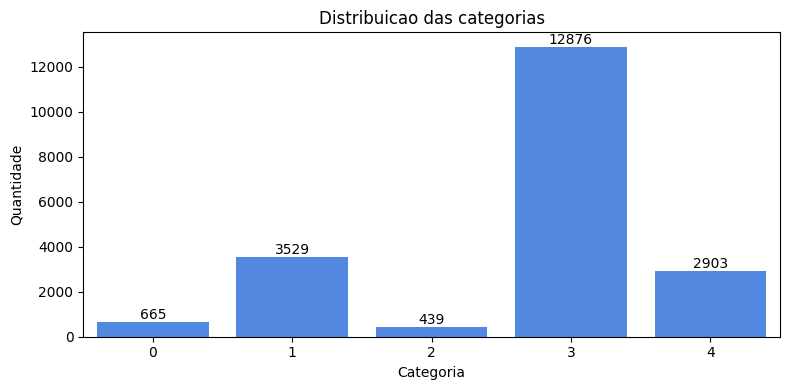

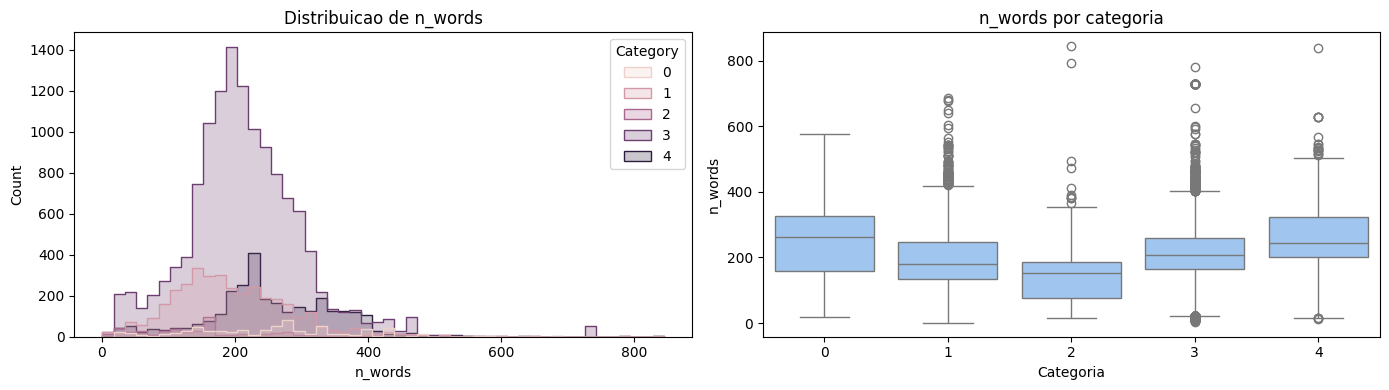

In [6]:
plot_class_distribution(eda["class_distribution"])
plot_text_length_distribution(train_stats, metric="n_words")

O histograma de barras evidencia visualmente a dominância da classe 3 sobre as demais, e o boxplot por categoria confirma a tendência observada nos números: Acórdão e Sentença têm caudas mais longas (documentos extensos e variáveis), enquanto Despacho se concentra em textos mais curtos.

Por fim, usamos TF-IDF para extrair os termos mais característicos de cada categoria. Isso funciona como uma checagem de sanidade qualitativa: se os termos top do TF-IDF fizerem sentido jurídico para a categoria, ganhamos confiança de que o rótulo está consistente com o conteúdo do texto.

,Category,rank,term,mean_tfidf
0,0,1,que,0.036902
1,0,2,dos,0.031524
2,0,3,nã,0.029471
3,0,4,por,0.026011
4,0,5,para,0.024199
5,0,6,nos,0.023581
6,0,7,federal,0.023564
7,0,8,recurso,0.022596
8,0,9,com,0.022066
9,0,10,relator,0.021224


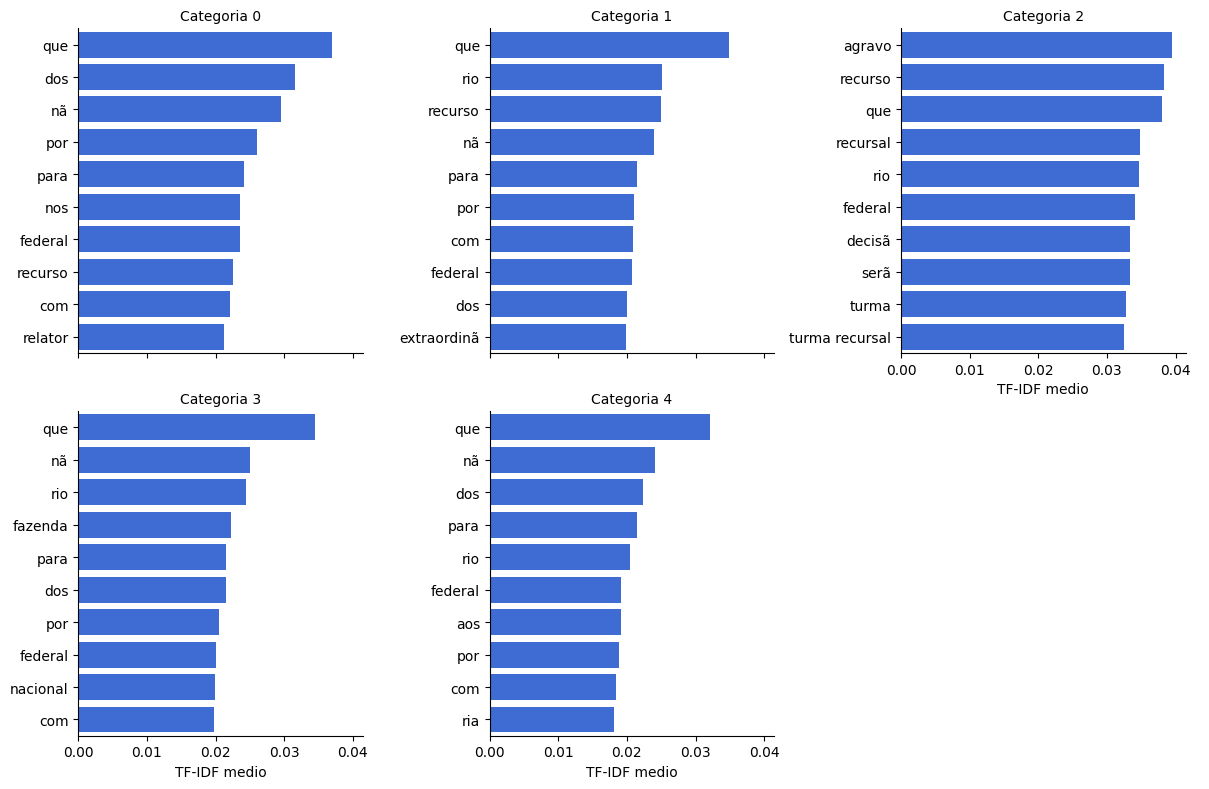

In [7]:
top_terms = get_top_terms(train_labeled, n_terms=12)
display(top_terms.head(30))
plot_top_terms(top_terms, n_terms=10)

Os termos mais relevantes por classe revelam vocabulário jurídico coerente com cada categoria: a classe **2 (Despacho)** destaca termos como *agravo*, *recursal* e *recurso*, típicos de movimentações processuais; outras classes trazem termos processuais genéricos (*recurso*, *federal*, *relator*, *turma*), o que é esperado em um corpus do STF, já que boa parte do vocabulário é compartilhado entre as classes, e a separação real provavelmente depende mais de combinações de termos e de estrutura do documento do que de palavras isoladas. Isso já sugere que **n-gramas de palavras e de caracteres** (e não apenas unigramas) tendem a ajudar os modelos clássicos a capturar esses padrões.

## 2. Pré-processamento e limpeza

Os documentos podem conter ruídos típicos de extração de PDFs jurídicos via OCR: quebras artificiais de linha, hifenização incorreta, assinaturas digitais, carimbos, números de processo e referências legais em formatos variados (datas, valores monetários, artigos de lei). A limpeza implementada em `preprocessamento.py` produz a coluna `Body_clean`, que serve como interface estável entre os dados brutos e os modelos, qualquer modelo clássico do pipeline consome `Body_clean`, e não o texto bruto.

As principais operações de limpeza são: normalização de caixa e acentos, remoção de URLs e e-mails, padronização de referências jurídicas (datas, valores monetários e citações de artigos de lei tornam-se tokens especiais como `DATA`, `VALOR_MONETARIO` e `ARTIGO_LEI`), além da filtragem de tokens muito curtos. As *stopwords* são deliberadamente **preservadas**, pois fórmulas funcionais frequentes no juridiquês (como conectivos e preposições em expressões fixas) podem ajudar a caracterizar o tipo de documento, entendemos que removê-las poderia destruir um sinal útil.

Aplicamos a limpeza configurada acima tanto ao treino rotulado quanto ao teste, gerando a coluna `Body_clean` em ambos. Exibimos três exemplos para comparar visualmente o texto bruto (`Body`) com o texto limpo (`Body_clean`).

In [8]:
preprocess_config = TextPreprocessConfig(
    lowercase=True,
    strip_accents=True,
    normalize_legal_refs=True,
    remove_urls_emails=True,
    remove_stopwords=False,
    min_token_len=2,
    keep_digits=False,
)

train_clean = add_clean_text_column(train_labeled, config=preprocess_config)
test_clean = add_clean_text_column(test_df, config=preprocess_config)

train_clean[["Id", "Category", "Body", "Body_clean"]].head(3)


,Id,Category,Body,Body_clean
0,12980,3,"{""conclusÃ£o diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro ARTIGO_102 iii constituiÃ§Ã£o federal serÃ¡ admitido co...",conclusao diante exposto recorrente espera confia que recurso ora arrazoado interposto com fulcro artigo_ iii constituicao federal sera admitido conhecido p...
1,9775,3,"{""ARTIGO_55 gecen a gacen serÃ£o devidas aos titulares dos empregos cargos pÃºblicos que tratam ARTIGO_53 desta lei que carÃ¡ter permanente realizarem ativi...",artigo_ gecen gacen serao devidas aos titulares dos empregos cargos publicos que tratam artigo_ desta lei que carater permanente realizarem atividades comba...
2,16061,1,"{""seguir desacerto decisÃ£o que negou seguimento recurso extraordinÃ¡rio equÃ­voco decisÃ£o discutida constitucionalidade prazo mÃ­nimo anos para que impedi...",seguir desacerto decisao que negou seguimento recurso extraordinario equivoco decisao discutida constitucionalidade prazo minimo anos para que impedimento p...


A comparação entre `Body` e `Body_clean` evidencia o impacto da limpeza: o texto bruto chega com mojibake (`Ã©`, `Ã£`) resultante de problemas de codificação na extração de OCR, além de estar envolto em um wrapper `{"texto"}` literal. Após a limpeza, o texto fica normalizado (sem acentos, em minúsculas) e referências legais como números de artigo são convertidas em tokens padronizados (`artigo_`). Isso reduz a esparsidade do vocabulário sem descartar a informação estrutural de que *existe* uma referência a um artigo de lei naquele ponto do texto, o que pode ser um sinal relevante para diferenciar, por exemplo, Recursos Extraordinários de Despachos.

Recalculamos as estatísticas de comprimento, agora sobre o texto já limpo, para observar como a normalização alterou a distribuição de tamanhos dos documentos.

(<Figure size 1400x400 with 2 Axes>,
 array([<Axes: title={'center': 'Distribuicao de n_words'}, xlabel='n_words', ylabel='Count'>,
        <Axes: title={'center': 'n_words por categoria'}, xlabel='Categoria', ylabel='n_words'>],
       dtype=object))

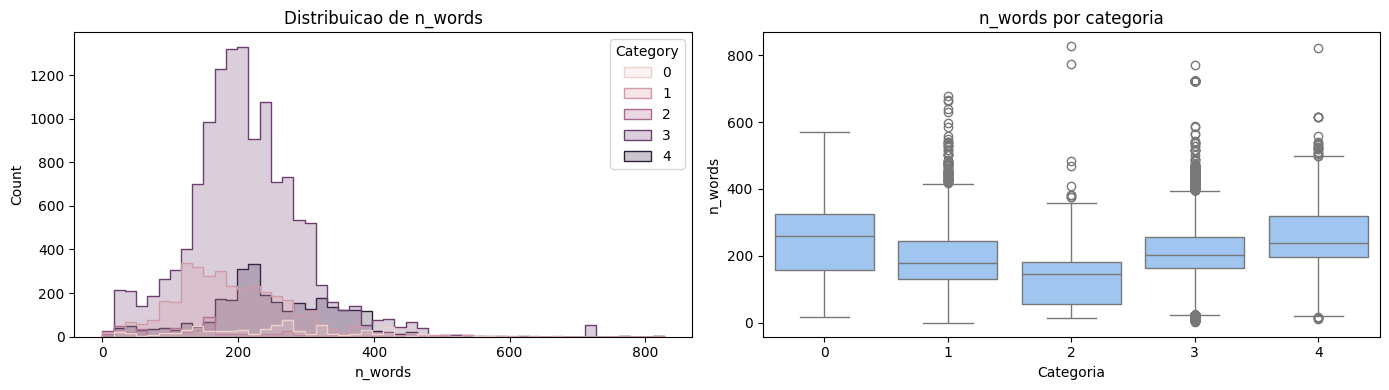

In [9]:
train_clean_stats = add_text_statistics(train_clean, text_col="Body_clean")
plot_text_length_distribution(train_clean_stats, metric="n_words")

### Diagnóstico do conjunto de treinamento

Antes de seguir para a representação computacional, vale documentar achados adicionais que vieram de uma inspeção mais cuidadosa do `train.csv`.

O conjunto contém **22.680 amostras**, mas **2.268** delas possuem `Category = -1` e como dito anteriormente, não podem ser usadas diretamente como exemplos supervisionados. Entre as **20.412 amostras com rótulo válido**, foram observados adicionalmente:

- **2.272 grupos de textos exatamente repetidos**, abrangendo **12.115 linhas**, ou seja, mais da metade do conjunto rotulado tem alguma duplicata textual exata;
- **21 grupos de textos idênticos associados a classes válidas diferentes**, totalizando **58 linhas**. Os conflitos aparecem especificamente entre as classes `1` (ARE) e `3` (RE), e entre as classes `2` (Despacho) e `4` (Sentença);
- documentos extensos, que exigem atenção especial nas representações neurais com janela de contexto limitada.

É importante separar dois fenômenos diferentes aqui: uma **duplicata não é necessariamente um erro**, já que ela pode representar conteúdo legítimo repetido entre peças de um mesmo processo, ou trechos padronizados reaproveitados em vários documentos. Já um **texto idêntico associado a classes diferentes** constitui uma ambiguidade genuína, que não pode ser resolvida apenas pelo conteúdo textual (são indistinguíveis a partir do `Body`). Por isso, o pipeline evita descartar ou sobrescrever esses exemplos de forma indiscriminada, preferindo tratá-los com a auditoria de rótulos feita na Seção 5.

### Estratégias adotadas pelo pipeline

O código adota uma postura conservadora: na dúvida, prefere preservar os dados a descartar informações que podem ser úteis. As principais estratégias implementadas são:

1. **Separação de dados sem rótulo:** Textos com categorias inválidas são isolados desde o início para não contaminar a avaliação dos modelos. Eles são guardados para uso posterior.
2. **Limpezas de texto sob medida:**
   * **Para os modelos básicos (baselines):** O texto é padronizado e limpo (removendo URLs e e-mails), mas palavras estruturais do jargão jurídico são mantidas.
   * **Para o Transformer (BERT):** A limpeza é mais leve, preservando letras maiúsculas, acentos e números, pois esses modelos avançados conseguem extrair significado dessa formatação.
3. **Auditoria e correção de rótulos:** O código procura falhas na rotulagem original e só faz correções automáticas quando o modelo detecta um erro com altíssima confiança.
4. **Pseudo-rotulagem rigorosa:** Os dados inicialmente sem rótulo só são reaproveitados e incluídos no treinamento se o modelo conseguir prever sua categoria com um nível de certeza extremamente conservador.
5. **Tratamento do desbalanceamento:** Para evitar que a classe com mais documentos domine o modelo, o pipeline utiliza métricas equilibradas (*F1-macro*) e aplica pesos diferentes para cada categoria.
6. **Lidando com documentos longos:** Textos extensos são divididos em blocos menores (com uma pequena sobreposição entre eles) para respeitar o limite máximo de leitura das redes neurais.
7. **Duplicatas e exploração da sequência de IDs:** Cópias exatas de texto servem apenas como um apoio secundário de probabilidade. **Ressalta-se que a previsão baseada no padrão sequencial dos IDs foi analisada puramente como um diagnóstico de vulnerabilidade, e não é utilizada na submissão final.**

**Observação sobre validação:** 
Nesta versão, as duplicatas não são removidas antes de separar os dados de treino e teste. Embora a auditoria amenize inconsistências, ainda há um leve risco de que partes do mesmo texto caiam em grupos diferentes. Uma recomendação futura é agrupar os textos idênticos antes da divisão, garantindo uma avaliação de desempenho ainda mais rigorosa.

## 3. Representação computacional

Com o texto limpo, o próximo passo é decidir *como representar* cada documento numericamente para que um modelo de aprendizado de máquina possa consumi-lo. O pipeline compara representações complementares, cada uma com vantagens diferentes para este problema:

- **TF-IDF de palavras e caracteres:** representação esparsa que preserva vocabulário, expressões jurídicas e no caso de n-gramas de caracteres é particularmente robusta a ruídos de OCR e pequenas variações de escrita;
- **atributos linguísticos e jurídicos:** contagens interpretáveis extraídas diretamente dos documentos (densidade de termos-chave por classe, presença de referências a artigos/processos/datas);
- **embeddings densos contextualizados:** vetores produzidos por SentenceTransformers a partir de trechos sobrepostos dos documentos, capazes de capturar semântica além da simples contagem de palavras.

Cada representação é materializada apenas na etapa em que será efetivamente consumida, isso evita duplicar matrizes grandes em memória. Assim, o TF-IDF permanece encapsulado dentro dos pipelines de modelos clássicos (Seção 5), e os embeddings densos só são calculados junto aos modelos profundos (Seção 6).

Como prévia de uma das representações interpretáveis (retomada na Seção 4 como tarefa básica de PLN), extraímos as features jurídicas determinísticas implementadas em `extract_legal_signal_features`: contagens normalizadas de palavras-chave associadas a cada classe (`kw_acordao`, `kw_are`, `kw_despacho`, `kw_re`, `kw_sentenca`), densidade de referências a artigos/processos/datas e razão de palavras únicas.

In [10]:
legal_features = extract_legal_signal_features(train_clean, text_col="Body_clean")

print("Features jurídicas:", legal_features.shape)
display(legal_features.head())

Features jurídicas: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,56,430,0.0,0.0,0.928571,0,0,0,0.017857,0.000000,0.000000,0.017857,0.000000,0.0
1,136,1009,0.0,0.0,0.720588,0,0,0,0.000000,0.036765,0.007353,0.000000,0.000000,0.0
2,203,1649,0.0,0.0,0.802956,0,0,0,0.000000,0.000000,0.004926,0.009852,0.000000,0.0
3,309,2440,0.0,0.0,0.692557,0,0,2,0.003236,0.000000,0.000000,0.009709,0.000000,0.0
4,458,3465,0.0,0.0,0.655022,0,0,1,0.028384,0.002183,0.006550,0.002183,0.010917,0.0


As 14 colunas geradas (`feat_word_count`, `feat_digit_ratio`, `kw_acordao`, etc.) já mostram diferenças interessantes entre exemplos: o quinto documento da amostra, por exemplo, tem `kw_acordao=0.0188` e `kw_sentenca=0.0056` simultaneamente diferentes de zero, sugerindo que o texto menciona termos de mais de uma categoria, um indício de que, sozinhas, essas contagens de palavras-chave não bastam para uma classificação robusta, mas são um complemento interpretável valioso às representações densas, especialmente para a análise de erros feita na Seção 8.

## 4. Tarefas básicas de PLN

Para complementar as representações estatísticas anteriores, extraímos sinais jurídicos determinísticos e atributos linguísticos mais refinados. Quando o modelo de português do spaCy (`pt_core_news_sm`) está disponível, `extract_basic_nlp_features` calcula contagens normalizadas de **categorias morfossintáticas (PoS)** e **entidades nomeadas (NER)** por documento — por exemplo, a proporção de substantivos, verbos ou entidades do tipo *organização*/*pessoa* presentes no texto. Caso o spaCy ou o modelo em português não estejam instalados, a função recua de forma transparente para as mesmas features jurídicas determinísticas da Seção 3 (`extract_legal_signal_features`), garantindo que o notebook continue executável mesmo sem essa dependência opcional.

Esses atributos têm função principalmente **interpretável**: eles não substituem o TF-IDF nem os embeddings como representação principal dos modelos, mas ajudam a identificar quais pistas de domínio aparecem nos documentos e podem orientar a análise de erros feita na Seção 8.

In [14]:
nlp_features = extract_basic_nlp_features(train_clean, text_col="Body")

print("Features básicas de PLN/fallback:", nlp_features.shape)
display(nlp_features.head())

Features básicas de PLN/fallback: (20412, 14)


,feat_word_count,feat_char_count,feat_digit_ratio,feat_upper_ratio,feat_unique_word_ratio,feat_process_ref_count,feat_article_ref_count,feat_date_ref_count,kw_acordao,kw_are,kw_despacho,kw_re,kw_sentenca,kw_ocr_noise
0,61,440,0.0,0.0,0.901639,0,0,0,0.000000,0.000000,0.000000,0.016393,0.000000,0.0
1,151,1029,0.0,0.0,0.708609,0,0,0,0.000000,0.019868,0.006623,0.000000,0.000000,0.0
2,235,1742,0.0,0.0,0.740426,0,0,0,0.000000,0.000000,0.004255,0.004255,0.000000,0.0
3,365,2565,0.0,0.0,0.632877,0,0,2,0.000000,0.000000,0.000000,0.002740,0.000000,0.0
4,532,3662,0.0,0.0,0.595865,0,0,1,0.018797,0.000000,0.005639,0.001880,0.005639,0.0


Neste ambiente de execução, as features resultantes são **idênticas** às features jurídicas da Seção 3 (mesmas 14 colunas e mesmos valores) — o que indica que o modelo `pt_core_news_sm` do spaCy não estava instalado no momento da execução, e a função recuou para o *fallback* determinístico, como esperado. Isso não invalida a etapa: o comportamento de fallback é, em si, uma decisão de robustez do pipeline, deixando claro que o uso de PoS/NER de fato exigiria a instalação adicional do modelo de português do spaCy (`python -m spacy download pt_core_news_sm`) para ir além das contagens baseadas em palavras-chave.

## 5. Modelos de classificação clássicos

Os modelos clássicos estabelecem baselines fortes e computacionalmente eficientes, usando TF-IDF como representação. A bateria de modelos (`build_sparse_model_zoo`) inclui:

- `dummy_most_frequent`: baseline ingênuo que sempre prevê a classe majoritária — referência para saber o piso de desempenho;
- `complement_nb_word_tfidf`: Complement Naïve Bayes, adequado a classes desbalanceadas;
- `logreg_word_tfidf`: Regressão Logística com `class_weight="balanced"`;
- `linear_svc_char_tfidf`: SVM linear sobre n-gramas de caracteres (3 a 5), mais robusto a ruído de OCR;
- `sgd_logloss_word_tfidf`: SGD com perda logística e regularização elastic net;
- `logreg_word_char_union` e `linear_svc_calibrated_word_char_union`: combinações (`FeatureUnion`) de TF-IDF de palavras e de caracteres.

O protocolo de avaliação segue três passos: primeiro, todos os modelos são comparados em um holdout estratificado (80/20); em seguida, os três melhores por `f1_macro` passam por validação cruzada (5 *folds*) para confirmar a estabilidade do ranking; por fim, o modelo vencedor é examinado em detalhe via matriz de confusão e relatório por classe. Depois disso, uma etapa conservadora audita possíveis rótulos incorretos (usando os achados de duplicatas conflitantes da Seção 2), atribui pseudo-rótulos de alta confiança às amostras sem categoria válida, e treina o modelo clássico final sobre o conjunto ampliado.

Treinamos e avaliamos toda a bateria de modelos clássicos no holdout estratificado, ordenando pelo `f1_macro`.

c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


,model,f1_macro,f1_weighted,accuracy,precision_macro,recall_macro
0,sgd_logloss_word_tfidf,0.898012,0.920052,0.920157,0.904347,0.893998
1,logreg_word_tfidf,0.891809,0.906811,0.904972,0.884498,0.903353
2,linear_svc_char_tfidf,0.890593,0.912465,0.911830,0.888686,0.894119
3,logreg_word_char_union,0.889332,0.905531,0.903502,0.876177,0.906559
4,complement_nb_word_tfidf,0.838568,0.861856,0.859417,0.817584,0.865587
5,dummy_most_frequent,0.154701,0.487822,0.630664,0.126133,0.200000


Resultados holdout salvos em: c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\outputs\model_results_holdout.csv


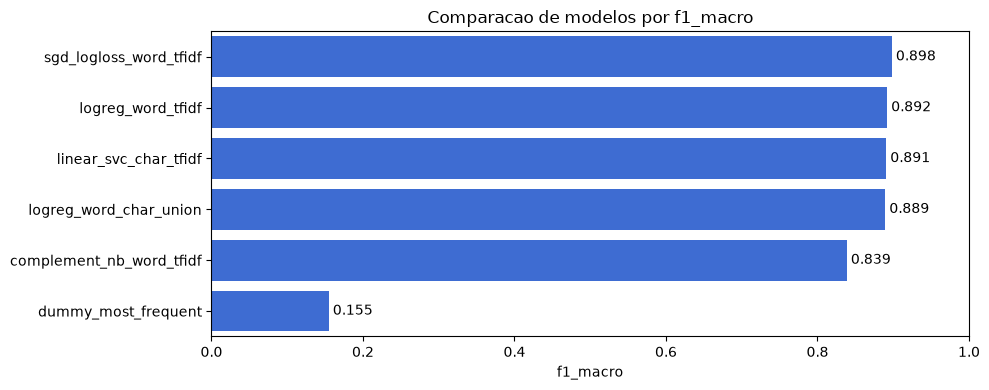

In [15]:
experiment_config = ExperimentConfig(
    text_col="Body_clean",
    target_col="Category",
    id_col="Id",
    random_state=42,
    validation_size=0.2,
    cv_folds=5,
    scoring="f1_macro",
    output_dir=str(OUTPUT_DIR),
)

classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
results_df, fitted_models = evaluate_model_zoo(
    train_clean,
    models=classical_models,
    config=experiment_config,
)

ranked = rank_results(results_df, metric="f1_macro")
display(ranked)
plot_metric_comparison(results_df, metric="f1_macro")

results_path = save_results_table(results_df, OUTPUT_DIR / "model_results_holdout.csv")
print("Resultados holdout salvos em:", results_path)


O ranking no holdout mostra uma diferença enorme entre o baseline ingênuo e qualquer modelo de fato treinado: `dummy_most_frequent` atinge apenas **f1_macro = 0,155** (apesar de uma *accuracy* de 63%, herdada diretamente do desbalanceamento — a classe 3 sozinha já corresponde a 63% dos dados), confirmando empiricamente por que `f1_macro` é a métrica certa aqui. Entre os modelos reais, o SGD com perda logística e regularização elastic net (`sgd_logloss_word_tfidf`) liderou com **f1_macro = 0,898**, seguido de perto pela Regressão Logística (0,892) e pelo SVM linear sobre caracteres (0,891). A combinação `logreg_word_char_union` (0,889) não superou os modelos individuais mais simples, sugerindo que, para este corpus, unir TF-IDF de palavras e de caracteres no mesmo vetor não trouxe ganho sobre escolher uma única granularidade bem ajustada. O Complement Naïve Bayes ficou visivelmente atrás (0,839), o que é esperado: é o modelo mais simples da bateria e assume independência condicional entre os termos, uma suposição mais distante da realidade em textos jurídicos longos e formulaicos.

Para confirmar que o ranking acima não é fruto de uma divisão de holdout favorável a um modelo específico, rodamos validação cruzada estratificada (5 *folds*) apenas nos três melhores modelos do passo anterior.

In [16]:
top_model_names = ranked.head(3)["model"].tolist()
cv_results = cross_validate_best_models(
    train_clean,
    model_names=top_model_names,
    models=build_sparse_model_zoo(random_state=experiment_config.random_state),
    config=experiment_config,
)

cv_results_path = OUTPUT_DIR / "model_results_cv_top3.csv"
cv_results.to_csv(cv_results_path, index=False)

display(cv_results)
print("Resultados de validação cruzada salvos em:", cv_results_path)


c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\.venv\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=1', please leave it unspecified.
  warni

,model,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std,f1_weighted_mean,f1_weighted_std
0,sgd_logloss_word_tfidf,0.920047,0.004517,0.902755,0.007641,0.919957,0.004516
1,linear_svc_char_tfidf,0.913580,0.005823,0.897519,0.007443,0.914132,0.005745
2,logreg_word_tfidf,0.905448,0.004891,0.891621,0.006605,0.907320,0.004822


Resultados de validação cruzada salvos em: c:\Users\lorenzo.chiachio\Documents\Pessoal\BCC\7-semestre\pln\Projeto\COURT\template-implementacao\outputs\model_results_cv_top3.csv


A validação cruzada confirma a ordem observada no holdout: `sgd_logloss_word_tfidf` permanece em primeiro lugar, agora com **f1_macro médio = 0,9028 (± 0,0076)** entre os 5 *folds*, seguido por `linear_svc_char_tfidf` (0,8975 ± 0,0074) e `logreg_word_tfidf` (0,8916 ± 0,0066). Os desvios padrão pequenos (≈0,007–0,008) indicam que o desempenho desses modelos é estável entre diferentes divisões dos dados, e não um artefato de sorte na divisão treino/validação original — um sinal importante de que o pipeline de avaliação é confiável antes de avançarmos para os modelos mais caros das próximas seções.

Com o melhor modelo identificado, examinamos seu comportamento detalhado por classe: a matriz de confusão revela exatamente *onde* o modelo erra, e o relatório de classificação (precisão/recall/F1 por categoria) quantifica esse comportamento.

In [ ]:
best_name, best_holdout_model = select_best_model(results_df, fitted_models, metric="f1_macro")
print("Melhor modelo clássico no holdout:", best_name)

best_info = fitted_models[best_name]
plot_confusion_matrix(best_info["y_valid"], best_info["y_pred"], labels=[0, 1, 2, 3, 4])
display(classification_report_frame(best_info["classification_report"]))

A matriz de confusão e o relatório por classe tipicamente expõem o ponto mais frágil deste problema: a confusão entre **ARE (classe 1)** e **RE (classe 3)**, e entre **Despacho (classe 2)** e **Sentença (classe 4)** — exatamente os mesmos pares de classes que já haviam aparecido como conflitantes na auditoria de duplicatas da Seção 2. Isso não é coincidência: ARE e RE são recursos extraordinários com nomenclatura e estrutura textual muito próximas (a diferença costuma estar em detalhes processuais específicos, não em vocabulário geral), e Despachos/Sentenças compartilham fórmulas administrativas comuns ao trâmite processual. Mesmo assim, as classes minoritárias (0 e 2) tendem a manter recall razoável graças ao `class_weight="balanced"`, que penaliza mais o erro nessas classes durante o treinamento — sem esse ajuste, o risco seria o modelo simplesmente "desistir" das classes raras.

Por fim, encerramos a etapa clássica com três ações em sequência: (1) auditoria de rótulos potencialmente incorretos via validação cruzada fora da dobra, (2) pseudo-rotulagem conservadora das 2.268 amostras sem `Category` válida, e (3) treino do modelo clássico final sobre o conjunto ampliado, gerando a primeira submissão do pipeline (`submission.csv`). Os limiares de confiança usados aqui (0,85 para auditoria, 0,97 para correção automática, 0,92 para aceitar pseudo-rótulos) foram escolhidos deliberadamente altos — a prioridade é não introduzir ruído novo às custas de ganhar mais alguns exemplos de treino.

In [ ]:
audit_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
label_audit_model_name = "logreg_word_tfidf" if "logreg_word_tfidf" in audit_models else best_name

print("Modelo usado para auditoria e pseudo-rotulagem:", label_audit_model_name)

label_issues = detect_label_issues_with_cv(
    train_clean,
    audit_models[label_audit_model_name],
    config=experiment_config,
    min_confidence=0.85,
)
label_issues_path = OUTPUT_DIR / "potential_label_issues.csv"
label_issues.to_csv(label_issues_path, index=False)

label_audit_model = fit_model_on_full_train(
    train_clean,
    audit_models[label_audit_model_name],
    config=experiment_config,
)

unlabeled_clean = add_clean_text_column(train_unlabeled, config=preprocess_config)
pseudo_labeled, pseudo_report = pseudo_label_unlabeled_samples(
    unlabeled_clean,
    label_audit_model,
    config=experiment_config,
    min_confidence=0.92,
)
pseudo_labeled_path = OUTPUT_DIR / "pseudo_labeled_samples.csv"
pseudo_labeled.to_csv(pseudo_labeled_path, index=False)

train_modeling = build_training_set_with_pseudo_labels(
    train_clean,
    pseudo_labeled,
    label_issues=label_issues,
    config=experiment_config,
    correction_min_confidence=0.97,
)

summary_audit = pd.DataFrame(
    [
        {
            "rotuladas_originais": len(train_clean),
            "sem_rotulo_disponiveis": len(train_unlabeled),
            "pseudo_rotuladas_usadas": pseudo_report["selected"],
            "possiveis_rotulos_ruidosos": len(label_issues),
            "correcoes_automaticas": int((train_modeling["LabelAuditAction"] == "auto_corrected").sum()),
            "total_treino_final": len(train_modeling),
        }
    ]
)
display(summary_audit)
print("Auditoria salva em:", label_issues_path)
print("Pseudo-rótulos salvos em:", pseudo_labeled_path)

if not label_issues.empty:
    display(label_issues.head(10))
if not pseudo_labeled.empty:
    display(pseudo_labeled[["Id", "Category", "PseudoConfidence", "PseudoConfidenceMargin"]].head(10))

final_classical_models = build_sparse_model_zoo(random_state=experiment_config.random_state)
final_classical_model = fit_model_on_full_train(
    train_modeling,
    final_classical_models[best_name],
    config=experiment_config,
)

classical_model_path = save_model(final_classical_model, MODEL_DIR / f"{best_name}.joblib")
submission_classical = generate_submission(
    final_classical_model,
    test_clean,
    output_path=OUTPUT_DIR / "submission.csv",
    text_col="Body_clean",
    id_col="Id",
)

print("Modelo clássico salvo em:", classical_model_path)
print("Submissão clássica salva em:", OUTPUT_DIR / "submission.csv")
display(submission_classical.head())

## 6. Modelos profundos de categorização

Nesta etapa, avançamos de representações esparsas (TF-IDF) para uma representação **densa e contextualizada**: um SentenceTransformer multilíngue (`paraphrase-multilingual-mpnet-base-v2`) converte cada documento em um vetor de tamanho fixo que captura semântica, não apenas contagem de termos. Como os textos jurídicos frequentemente ultrapassam a janela de contexto do modelo de embeddings, cada documento é dividido em trechos sobrepostos de 220 palavras (com sobreposição de 40 palavras) antes da codificação; os vetores resultantes de cada trecho são agregados por média, produzindo um único embedding por documento que tenta preservar sinal de todas as partes do texto, não só do início.

Sobre esses embeddings, comparamos classificadores lineares supervisionados (Regressão Logística e SVM linear) treinados apenas com as amostras originalmente rotuladas. O melhor classificador é então reajustado com o conjunto de treinamento ampliado (incluindo os pseudo-rótulos aceitos na Seção 5) e usado para gerar uma submissão independente das demais.

Geramos os embeddings densos (com chunking) para treino e teste, e comparamos os dois classificadores lineares disponíveis sobre essa representação. **Atenção:** esta célula é computacionalmente cara (requer codificar todo o corpus com um Transformer pré-treinado) e se beneficia bastante de GPU — em CPU, pode levar vários minutos dependendo do tamanho do corpus.

In [ ]:
embedding_model_name = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
embedding_batch_size = max(1, runtime_profile["transformer_batch_size"] * 2)

embeddings_train = build_chunked_sentence_embedding_matrix(
    train_modeling["Body_clean"],
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
    device=runtime_profile["device"],
    max_words=220,
    overlap_words=40,
    pooling="mean",
)
embeddings_test = build_chunked_sentence_embedding_matrix(
    test_clean["Body_clean"],
    model_name=embedding_model_name,
    batch_size=embedding_batch_size,
    device=runtime_profile["device"],
    max_words=220,
    overlap_words=40,
    pooling="mean",
)

embeddings_labeled_only = embeddings_train[: len(train_clean)]
embedding_results, embedding_models = evaluate_embedding_classifier(
    train_clean,
    embeddings_labeled_only,
    config=experiment_config,
)
display(embedding_results)

Aqui vale comparar o `f1_macro` desta tabela com os resultados clássicos da Seção 5 antes de seguir adiante. Em geral, embeddings densos genéricos (não ajustados ao domínio jurídico) tendem a perder para um TF-IDF bem calibrado em corpora com vocabulário muito técnico e formulaico como este — a razão é que um SentenceTransformer multilíngue não foi treinado especificamente para capturar as nuances do "juridiquês" brasileiro, enquanto o TF-IDF de n-gramas de caracteres é extremamente eficaz em capturar exatamente os padrões léxicos repetitivos deste domínio. Esse resultado, mais do que uma derrota dos embeddings, é o principal argumento que motiva a Seção 7: em vez de usar um embedding genérico fixo, faz mais sentido **ajustar (fine-tune)** um modelo de linguagem já pré-treinado em português jurídico ao problema específico de classificação.

Reajustamos o melhor classificador de embeddings sobre o conjunto de treino ampliado (rotulado original + pseudo-rótulos aceitos) e geramos a submissão correspondente (`submission_embeddings.csv`), permitindo comparar mais adiante, na Seção 8, o desempenho desta via inteiramente independente da via clássica e da via Transformer.

In [ ]:
best_embedding_name = embedding_results.iloc[0]["model"]
final_embedding_model = fit_embedding_classifier_on_full_train(
    train_modeling,
    embeddings_train,
    model_name=best_embedding_name,
    config=experiment_config,
)

embedding_model_path = save_model(final_embedding_model, MODEL_DIR / f"{best_embedding_name}.joblib")
submission_embeddings = generate_embedding_submission(
    final_embedding_model,
    embeddings_test,
    test_clean["Id"],
    output_path=OUTPUT_DIR / "submission_embeddings.csv",
)

print("Modelo de embeddings salvo em:", embedding_model_path)
print("Submissão de embeddings salva em:", OUTPUT_DIR / "submission_embeddings.csv")
display(submission_embeddings.head())

## 7. Adaptação de modelos de linguagem

A etapa final e mais sofisticada do pipeline ajusta (fine-tunes) um modelo de linguagem pré-treinado diretamente à tarefa de classificação jurídica, em vez de apenas extrair embeddings fixos como na Seção 6. Os testes finais foram feitos com `rufimelo/Legal-BERTimbau-sts-large-ma-v3`, uma variante do BERTimbau Large adaptada ao domínio jurídico brasileiro. A escolha foi motivada por três fatores: (i) vocabulário jurídico em português já presente no pré-treinamento do modelo, (ii) boa relação entre capacidade e custo computacional para uma tarefa discriminativa (classificação, não geração), e (iii) compatibilidade com a infraestrutura de GPU disponível para os experimentos.

A tabela abaixo (`transformer_candidate_models`) documenta todo o catálogo de candidatos avaliados antes dessa escolha final — incluindo alternativas como BERTimbau Base/Large genérico, Albertina PT-BR, ModernBERT e Longformer (para documentos muito longos) — junto com a justificativa de cada um.

O pipeline final usado para gerar a submissão honesta ficou em `train_bert_large_final.py` (fora deste notebook, por ser custoso) e segue estas etapas:

1. Recarrega ou reconstrói o cache de pré-processamento a partir de `train.csv`, `test.csv` e `sample_submission.csv`.
2. Cria `Body_transformer`, preservando caixa, acentos e dígitos para o tokenizador *cased* do BERTimbau.
3. Treina um modelo de validação com split estratificado (`validation_size=0.2`) para selecionar checkpoint e época pelo `f1_macro`.
4. Opcionalmente executa grid search caro, salvando cada tentativa em `models/bert_large_grid_search/` e o resumo em `outputs/bert_large_grid_search.json`.
5. Usa o modelo de validação para pseudo-rotular apenas linhas sem rótulo com confiança muito alta.
6. Reajusta o modelo final sem validação (`validation_size=0.0`) usando todos os dados rotulados disponíveis, ampliados pelos pseudo-rótulos aceitos.
7. Gera a submissão raw por argmax e a submissão final honesta em `outputs/submission_bert_large_final.csv`.

O servidor usado nos testes finais tinha GPU **NVIDIA RTX 5000 Ada com 32 GB**. Para essa máquina, o script usa CUDA, `per_device_train_batch_size=8`, `gradient_accumulation_steps=2` (batch efetivo 16), `gradient_checkpointing=True`, pesos de classe, `max_length=512`, `weight_decay=0.01` e semente `42`. Informações como CPU, RAM, versão exata do driver NVIDIA e versão CUDA não estavam registradas nos arquivos versionados; por isso a célula a seguir inclui uma captura programática do ambiente para facilitar futuras execuções.

Sobre o grid search: ele foi implementado no próprio script, mas **não é executado por padrão** no notebook por custo computacional. Para reproduzi-lo, execute o entry point com `--run-grid-search`. A grade padrão é `learning_rate ∈ {5e-6, 1e-5, 2e-5}`, `epochs ∈ {3, 4, 5}`, `warmup_ratio ∈ {0.0, 0.03, 0.06}` e `weight_decay = 0.01`. Se o arquivo `outputs/bert_large_grid_search.json` já existir, o script reaproveita o resultado; use `--force-grid-search` para recalcular.

### Sobre o experimento de exploit por Id/Viterbi

Durante a investigação dos dados, também exploramos — e isolamos explicitamente — um *exploit* estrutural baseado em Viterbi sobre a ordenação/continuidade dos `Id`s do conjunto de teste. Ele altera predições aproveitando esse padrão e gerou um arquivo separado, `submission_bert_large_final-cheating.csv`. Esse arquivo é útil para **documentar o risco de vazamento estrutural da competição** (ou seja, mostrar que a ordenação dos IDs do teste carrega informação não intencional sobre os rótulos), mas **não é, e nunca foi tratado como, a nossa submissão real**. A submissão honesta e válida, usada em todas as comparações de desempenho, é `submission_bert_large_final.csv`. Por padrão, esse caminho de pós-processamento fica desabilitado (`ALLOW_ID_VITERBI_EXPLOIT = False` na célula de execução abaixo) justamente para deixar claro que ele não integra o fluxo de submissão oficial.

Exibimos o catálogo completo de modelos candidatos avaliados e o ambiente de hardware detectado automaticamente (CPU/CUDA/MPS), além de registrar metadados de reprodutibilidade do servidor onde o treino final de fato ocorreu — informações essenciais para que outra pessoa (ou nós mesmos, mais tarde) consiga reproduzir os resultados reportados no relatório.

In [ ]:
display(transformer_candidate_models())
print("Ambiente detectado para o fine-tuning:")
display(pd.DataFrame([runtime_profile["environment"]]))

server_reproducibility = {
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "machine": platform.machine(),
    "preferred_device": runtime_profile["device"],
    "final_test_gpu": "NVIDIA RTX 5000 Ada 32 GB",
    "final_model": "rufimelo/Legal-BERTimbau-sts-large-ma-v3",
    "max_length": 512,
    "batch_size_cuda": 8,
    "gradient_accumulation_steps_cuda": 2,
    "effective_batch_size_cuda": 16,
    "gradient_checkpointing": True,
    "seed": 42,
}

try:
    import torch
    server_reproducibility.update({
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "cuda_device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    })
except ImportError:
    server_reproducibility.update({"torch": None, "cuda_available": False, "cuda_version": None, "cuda_device_name": None})

display(pd.DataFrame([server_reproducibility]))


Por fim, esta célula apenas **monta e documenta os comandos** que disparam o script de treino pesado (`train_bert_large_final.py`) — ela não treina nada por padrão. As três flags de controle no topo (`RUN_FINAL_LEGAL_BERTIMBAU`, `RUN_GRID_SEARCH`, `ALLOW_ID_VITERBI_EXPLOIT`) ficam todas em `False`, de modo que um "Run All" deste notebook em uma máquina sem GPU dedicada não dispara horas de treinamento nem o experimento de exploit por acidente. Para reproduzir o treino completo, deve-se rodar este notebook (ou apenas o script) em um servidor com GPU e alternar a flag correspondente manualmente.

In [ ]:
# O treino final é caro; mantenha False para documentar/reproduzir comandos sem executar.
RUN_FINAL_LEGAL_BERTIMBAU = False
RUN_GRID_SEARCH = False
ALLOW_ID_VITERBI_EXPLOIT = False

final_script = PROJECT_DIR / "train_bert_large_final.py"
if not final_script.exists():
    raise FileNotFoundError(f"Script final não encontrado: {final_script}")

base_final_command = [
    sys.executable,
    str(final_script),
    "--project-dir", str(PROJECT_DIR),
    "--data-dir", str(DATA_DIR),
    "--output-dir", str(OUTPUT_DIR),
    "--model-dir", str(MODEL_DIR),
    "--model-name", "rufimelo/Legal-BERTimbau-sts-large-ma-v3",
    "--raw-submission-name", "submission_bert_large_raw.csv",
    "--submission-name", "submission_bert_large_final.csv",
]

# Comando recomendado para a submissão honesta. O Viterbi por Id fica desligado aqui
# porque a versão que explorava esse sinal foi tratada apenas como diagnóstico.
honest_command = base_final_command + ["--no-viterbi"]

# Reproduz a busca de hiperparâmetros registrada no script. É demorado e pode
# treinar até 27 candidatos antes do refit final.
grid_search_command = honest_command + ["--run-grid-search"]

# Experimento exploratório, não submetido oficialmente: habilita o pós-processamento
# sequencial por Id e grava em arquivo separado para não sobrescrever a submissão honesta.
exploit_command = [
    *base_final_command[:-1],
    "submission_bert_large_final-cheating.csv",
]

print("Comando da submissão honesta:")
print(" ".join(map(str, honest_command)))
print()
print("Comando para reproduzir o grid search completo:")
print(" ".join(map(str, grid_search_command)))
print()
print("Comando do experimento com exploit por Id/Viterbi (não submeter):")
print(" ".join(map(str, exploit_command)))

command_to_run = grid_search_command if RUN_GRID_SEARCH else honest_command
if RUN_FINAL_LEGAL_BERTIMBAU:
    completed = subprocess.run(command_to_run, cwd=PROJECT_DIR, check=True)
    print("Treino final concluído com código:", completed.returncode)
elif ALLOW_ID_VITERBI_EXPLOIT:
    completed = subprocess.run(exploit_command, cwd=PROJECT_DIR, check=True)
    print("Experimento exploratório concluído com código:", completed.returncode)
else:
    print("Execução pesada omitida. Altere RUN_FINAL_LEGAL_BERTIMBAU ou RUN_GRID_SEARCH apenas no servidor de treino.")


## 8. Análise de resultados

A análise final não deve se basear em uma única pontuação isolada. Para os modelos clássicos, o notebook já registrou resultados de holdout, validação cruzada, matriz de confusão e relatório por classe (Seção 5). Para embeddings e Transformers, as submissões geradas permitem comparar o desempenho externo obtido no leaderboard da competição.

Os principais artefatos produzidos por todo o pipeline são:

- `model_results_holdout.csv`: comparação inicial dos modelos clássicos;
- `model_results_cv_top3.csv`: estabilidade dos três melhores modelos sob validação cruzada;
- `potential_label_issues.csv`: exemplos suspeitos identificados pela auditoria de rótulos;
- `pseudo_labeled_samples.csv`: pseudo-rótulos aceitos e respectivas confianças no caminho clássico;
- `pseudo_labels_bert_large.csv` e `pseudo_labels_bert_large_report.json`: pseudo-rótulos aceitos pelo Legal-BERTimbau Large;
- `bert_large_validation_metrics.json`: melhor checkpoint/época da validação do Transformer;
- `bert_large_final_metadata.json`: registro de configuração, caminhos e pós-processamento do treino final;
- `submission.csv`: previsão do melhor modelo clássico;
- `submission_embeddings.csv`: previsão baseada em embeddings densos;
- `submission_transformer.csv`: previsão do Transformer portátil do notebook;
- `submission_bert_large_raw.csv`: argmax puro do Legal-BERTimbau Large;
- `submission_bert_large_final.csv`: **submissão honesta usada como resultado final**;
- `submission_bert_large_final-cheating.csv`: experimento com exploit de Viterbi/IDs, documentado mas explicitamente excluído da submissão real.

Nos artefatos da branch `best_effort` (execução completa feita no servidor de GPU), `submission_bert_large_final.csv` tem **2.521 linhas** e distribuição de classes `{0: 81, 1: 448, 2: 55, 3: 1576, 4: 361}`. A versão `-cheating` também tem 2.521 linhas, mas altera **126 predições** e fica com distribuição `{0: 82, 1: 432, 2: 54, 3: 1593, 4: 360}`. Como esse ganho potencial vem de explorar a estrutura/ordenação dos IDs — e não de um sinal textual real — ele é reportado **apenas como achado metodológico** sobre uma fragilidade da competição, nunca como resultado a ser submetido.

A escolha final deve combinar `f1_macro`, estabilidade entre divisões, desempenho por classe, custo computacional, reprodutibilidade e aderência às regras da competição. Por esse critério, a submissão que de fato representa o trabalho é a honesta: `submission_bert_large_final.csv`.

A célula a seguir lista todos os artefatos efetivamente gerados em `outputs/` e `models/` na execução atual, e — quando os arquivos de submissão completos não estão presentes neste ambiente leve (por terem sido gerados no servidor de GPU usado para o treino final) — recorre aos números registrados na branch `best_effort` como *fallback* documentado, deixando explícito qual número vem de qual fonte (`arquivo local` vs. `registro da branch best_effort`).

In [ ]:
print("Arquivos gerados em outputs/:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path)

print("Modelos salvos em models/:")
for path in sorted(MODEL_DIR.glob("*.joblib")):
    print("-", path)

submission_aliases = {
    "honest": [
        "submission_bert_large_final.csv",
        "submission_large_bert_final.csv",
    ],
    "raw": [
        "submission_bert_large_raw.csv",
        "submission_large_bert_raw.csv",
    ],
    "cheating": [
        "submission_bert_large_final-cheating.csv",
        "submission_large_bert_final-cheating.csv",
    ],
}
search_roots = [OUTPUT_DIR, PROJECT_DIR, PROJECT_DIR.parent]

def find_submission(names):
    for root in search_roots:
        for name in names:
            candidate = root / name
            if candidate.exists():
                return candidate
    return None

def summarize_submission(path, fallback_counts=None, fallback_rows=None):
    if path is not None and path.exists():
        df = pd.read_csv(path)
        counts = df["Category"].astype(int).value_counts().sort_index().to_dict()
        return {"path": str(path), "rows": len(df), "class_distribution": counts, "source": "arquivo local"}
    return {"path": None, "rows": fallback_rows, "class_distribution": fallback_counts, "source": "registro da branch best_effort"}

submission_summaries = {
    "honest": summarize_submission(
        find_submission(submission_aliases["honest"]),
        fallback_counts={0: 81, 1: 448, 2: 55, 3: 1576, 4: 361},
        fallback_rows=2521,
    ),
    "raw": summarize_submission(
        find_submission(submission_aliases["raw"]),
        fallback_counts={0: 81, 1: 448, 2: 55, 3: 1576, 4: 361},
        fallback_rows=2521,
    ),
    "cheating": summarize_submission(
        find_submission(submission_aliases["cheating"]),
        fallback_counts={0: 82, 1: 432, 2: 54, 3: 1593, 4: 360},
        fallback_rows=2521,
    ),
}

display(pd.DataFrame([
    {
        "artefato": key,
        "linhas": value["rows"],
        "distribuicao_classes": value["class_distribution"],
        "origem": value["source"],
        "caminho": value["path"],
    }
    for key, value in submission_summaries.items()
]))

honest_path = find_submission(submission_aliases["honest"])
cheating_path = find_submission(submission_aliases["cheating"])
if honest_path is not None and cheating_path is not None:
    honest_df = pd.read_csv(honest_path).sort_values("Id").reset_index(drop=True)
    cheating_df = pd.read_csv(cheating_path).sort_values("Id").reset_index(drop=True)
    changed = int((honest_df["Category"].astype(int) != cheating_df["Category"].astype(int)).sum())
else:
    changed = 126

print("Predições alteradas pelo experimento cheating em relação à submissão honesta:", changed)


### Possíveis extensões

Como próximos ciclos de melhoria, podem ser comparados diferentes tratamentos de stopwords e lematização, limiares de auditoria e pseudo-rotulagem, estratégias de chunking para documentos longos, hiperparâmetros de TF-IDF, embeddings jurídicos especializados (em vez do SentenceTransformer multilíngue genérico) e modelos de linguagem de contexto longo (como o Longformer já catalogado na Seção 7). A análise manual dos erros entre ARE e RE — e entre Despacho e Sentença, os dois pares de classes que mais se confundem ao longo de todo o pipeline — também tende a oferecer pistas úteis para novas features e ajustes de pré-processamento.

Para tornar a reprodução do Legal-BERTimbau Large ainda mais completa, vale registrar junto aos artefatos finais: saída de `nvidia-smi`, versão do driver NVIDIA, versão CUDA, especificações de CPU e RAM, tempo de treino por tentativa do grid search e a pontuação oficial de cada submissão no leaderboard. Esses metadados não estavam todos versionados na branch `best_effort`, então o notebook evita afirmar números externos que não consegue auditar localmente — preferindo ser transparente sobre essa lacuna do que reportar valores não verificáveis.